In [3]:
# Автонастройка импорта: ноутбук работает без предварительного pip install.
from pathlib import Path
import importlib
import sys

cwd = Path.cwd().resolve()
candidates = [
    cwd / "src",
    cwd.parent / "src",
    cwd / "demo" / "evt-educational-demo" / "src",
]
src = next((path for path in candidates if (path / "evt_demo" / "__init__.py").exists()), None)
if src is None:
    raise RuntimeError("Не найден demo/evt-educational-demo/src; запустите ноутбук из репозитория")
sys.path.insert(0, str(src))
for module_name in [name for name in sys.modules if name == "evt_demo" or name.startswith("evt_demo.")]:
    del sys.modules[module_name]
importlib.invalidate_caches()
print(f"evt_demo: {src}")

evt_demo: /Users/denmacair/Documents/code_base/Extreme-Value-Theory-New-Approach/demo/evt-educational-demo/src


# 2. EVT-детекция момента

POT/GPD моделирует превышения фонового графового индикатора и задаёт порог редкого события.

4

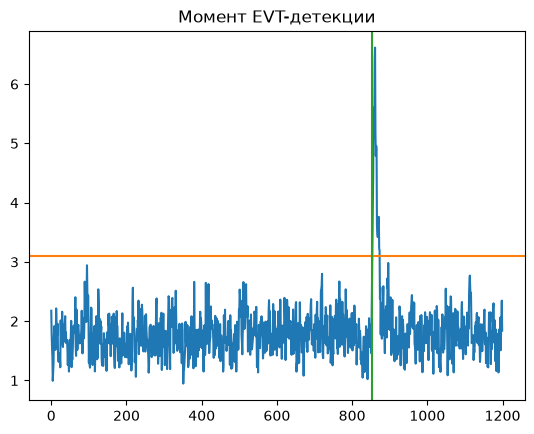

In [4]:
import matplotlib.pyplot as plt
from evt_demo import EVTEventDetector, generate_graph_time_series
series=generate_graph_time_series(seed=42)
detection=EVTEventDetector(700).fit_detect(series.values)
plt.plot(detection.indicator); plt.axhline(detection.threshold,color="tab:orange"); plt.axvline(detection.detected_at,color="tab:green"); plt.title("Момент EVT-детекции");
detection.detected_at-series.event_onset

Задержка измеряется относительно истинного момента, доступного здесь благодаря генератору.